# Step 14 --- 1D Gravity Waves (Linear Shallow Water)

The linear shallow water equations describe gravity waves in a thin
layer of fluid. A height perturbation splits into two waves
propagating at the phase speed $c = \sqrt{gH_0}$.

This tutorial demonstrates:
- Creating a 1D linear shallow water model with `somax`
- Gravity wave propagation and phase speed verification
- Saving snapshots to `xarray` and creating a GIF animation

In [1]:
import diffrax as dfx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.animation import FuncAnimation, PillowWriter

from somax.models import LinearShallowWater1D, LinearSW1DState

## Model Setup

We create a 1D domain of length 2000 km with 400 grid cells.
The mean depth is 100 m, giving a phase speed of ~31.3 m/s.

In [2]:
nx, Lx = 400, 2e6
g, H0 = 9.81, 100.0
model = LinearShallowWater1D.create(nx=nx, Lx=Lx, g=g, f0=0.0, H0=H0)

c = float(jnp.sqrt(g * H0))
print(f"Phase speed: c = sqrt(g*H0) = {c:.1f} m/s")
print(f"Grid spacing: dx = {model.grid.dx / 1e3:.1f} km")

Phase speed: c = sqrt(g*H0) = 31.3 m/s
Grid spacing: dx = 5.0 km


## Initial Condition

A Gaussian height perturbation centered in the domain.

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
x0, sigma = Lx / 2.0, Lx / 20.0
h0 = jnp.exp(-0.5 * ((x - x0) / sigma) ** 2)
u0 = jnp.zeros_like(h0)
v0 = jnp.zeros_like(h0)

state0 = LinearSW1DState(h=h0, u=u0, v=v0)

## Integration

We integrate for ~18 hours, saving 200 snapshots.

In [4]:
t_final = 6.5e4  # ~18 hours
n_frames = 200
ts = jnp.linspace(0.0, t_final, n_frames)
dt = 0.5 * model.grid.dx / c  # CFL < 1

sol = model.integrate(state0, t0=0.0, t1=t_final, dt=dt, saveat=dfx.SaveAt(ts=ts))
print(f"All finite: {bool(jnp.all(jnp.isfinite(sol.ys.h)))}")

All finite: True


## Save to xarray

In [5]:
x_km = np.asarray(x[1:-1]) / 1e3
ds = xr.Dataset(
    {
        "h": (["time", "x"], np.asarray(sol.ys.h[:, 1:-1])),
        "u": (["time", "x"], np.asarray(sol.ys.u[:, 1:-1])),
    },
    coords={
        "time": np.asarray(ts) / 3600.0,  # hours
        "x": x_km,
    },
    attrs={"phase_speed_m_s": c, "H0_m": H0, "Lx_m": Lx},
)
ds

<xarray.Dataset> Size: 642kB
Dimensions:  (time: 200, x: 400)
Coordinates:
  * time     (time) float32 800B 0.0 0.09073 0.1815 0.2722 ... 17.87 17.96 18.06
  * x        (x) float32 2kB 5.0 10.0 15.0 20.0 ... 1.99e+03 1.995e+03 2e+03
Data variables:
    h        (time, x) float32 320kB 3.176e-22 5.217e-22 ... -1.535e-06
    u        (time, x) float32 320kB 0.0 0.0 0.0 ... 2.157e-07 -2.157e-07
Attributes:
    phase_speed_m_s:  31.320919036865234
    H0_m:             100.0
    Lx_m:             2000000.0

## Create GIF Animation

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
(line,) = ax.plot(ds.x.values, ds["h"].isel(time=0).values, "b-", lw=1.5)
ax.set_xlim(ds.x.values[0], ds.x.values[-1])
ax.set_ylim(-0.6, 1.1)
ax.set_xlabel("x (km)")
ax.set_ylabel("h (m)")
title = ax.set_title("t = 0.0 h")
ax.axhline(0, color="gray", ls="--", lw=0.5)


def update(frame):
    line.set_ydata(ds["h"].isel(time=frame).values)
    title.set_text(f"t = {ds.time.values[frame]:.1f} h")
    return (line, title)


anim = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)
anim.save("step14_gravity_waves_1d.gif", writer=PillowWriter(fps=20), dpi=80)
plt.close()

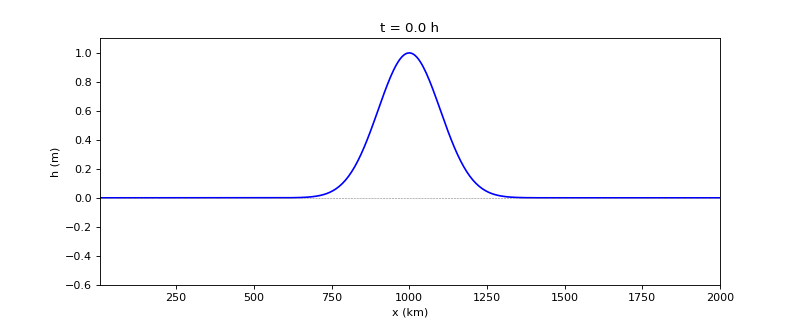

In [7]:
from IPython.display import Image, display

display(Image(filename="step14_gravity_waves_1d.gif"))

## Phase Speed Verification

The initial Gaussian splits into two waves moving at $\pm c$.
After time $t$, the right-moving peak should be at $x_0 + ct$.

In [8]:
t_check = t_final
mu_right = (x0 + c * t_check) % Lx
mu_left = (x0 - c * t_check) % Lx
h_final = sol.ys.h[-1, 1:-1]
expected = 0.5 * (
    jnp.exp(-0.5 * ((x[1:-1] - mu_right) / sigma) ** 2)
    + jnp.exp(-0.5 * ((x[1:-1] - mu_left) / sigma) ** 2)
)
corr = float(
    jnp.sum(h_final * expected) / jnp.sqrt(jnp.sum(h_final**2) * jnp.sum(expected**2))
)
print(f"Correlation with analytical: {corr:.4f}")

Correlation with analytical: 1.0000


## Differentiability

`jax.grad` flows through the model parameters.

In [9]:
import equinox as eqx


@eqx.filter_grad
def grad_fn(m):
    sol = m.integrate(state0, t0=0.0, t1=1000.0, dt=dt)
    return jnp.sum(sol.ys.h**2)


grads = grad_fn(model)
print(f"d(loss)/d(viscosity) = {float(grads.params.lateral_viscosity):.6f}")
print(f"d(loss)/d(drag)      = {float(grads.params.bottom_drag):.6f}")

d(loss)/d(viscosity) = 0.000000
d(loss)/d(drag)      = 530.228271


## Summary

- The linear shallow water equations support gravity waves at speed $c = \sqrt{gH_0}$
- A Gaussian splits into two counter-propagating waves
- The `somax` model is fully differentiable through `jax.grad`

**Next:** [Step 15 --- 1D Nonlinear Shallow Water](step15_shallow_water_1d.py)